<a href="https://colab.research.google.com/github/hmmnyamminji/python/blob/main/Chapter04_%EB%B6%84%EB%A5%98(3)_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 구글 드라이브 마운트
from google.colab import drive, files
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트를 관리하는 모듈
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve
)

In [13]:
# 통합 평가 함수
def get_clf_eval(y_test, pred=None, pred_proba=None):
  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)
  f1 = f1_score(y_test, pred)
  roc_auc = roc_auc_score(y_test, pred_proba)

  print('오차 행렬')
  print(confusion)
  print(f'정확도: {accuracy:.4f}')
  print(f'정밀도: {precision:.4f}')
  print(f'재현율: {recall:.4f}')
  print(f'F1: {f1:.4f}')
  print(f'ROC AUC: {roc_auc:.4f}')

In [1]:
# 모델 학습/예측/평가 통합 함수
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
  model.fit(ftr_train, tgt_train)
  pred = model.predict(ftr_test)
  pred_proba = model.predict_proba(ftr_test)[:, 1]
  get_clf_eval(tgt_test, pred, pred_proba)


### 신용카드 사기 검출

In [6]:
import pandas as pd
# 데이터 로딩
card_df =pd.read_csv('/content/drive/MyDrive/kwu/ML/data/creditcard.csv')
print('데이터 크기:', card_df.shape)
card_df.head(3)

데이터 크기: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# 레이블 불균형 확인, Class : 레이블 (0=정상, 1=사기)
print('레이블 분포:')
print(card_df['Class'].value_counts())
print(f'사기비율: {round(card_df['Class'].mean()*100, 4)}%')

레이블 분포:
Class
0    284315
1       492
Name: count, dtype: int64
사기비율: 0.1727%


In [14]:
# STEP 1: 기본 전처리 - Time 컬럼만 제거
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

def get_preprocessed_df(df=None):
  df_copy = df.copy()
  df_copy.drop('Time', axis=1, inplace=True)
  return df_copy

def get_train_test_dataset(df=None):
  df_copy = get_preprocessed_df(df)
  X_features = df_copy.iloc[:, :-1]
  y_target = df_copy.iloc[:, -1]

  X_train, X_test, y_train, y_test = train_test_split(
      X_features, y_target, test_size=0.3, random_state=0, stratify=y_target
  )
  return X_train, X_test, y_train, y_test

# 데이터 분할 및 불균형 비율 확인
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)
print(f'학습 데이터 사기 비율: {y_train.mean() * 100:.4f}%')
print(f'테스트 데이터 사기 비율: {y_test.mean() * 100:.4f}%')

# 로지스틱 회귀 기본 평가 (아무 처리 없는 베이스라인)
lr_clf = LogisticRegression(max_iter=1000) # max_iter: 최적화 알고리즘 경사 하강법(Gradient Descent)의 최대 반복
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, lr_pred, lr_pred_proba)

학습 데이터 사기 비율: 0.1725%
테스트 데이터 사기 비율: 0.1732%


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_13711/3161633310.py", line 53, in <cell line: 0>
    lr_clf.fit(X_train, y_train)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1350, in fit
    fold_coefs_ = Parallel(n_jobs=self.n_jobs, verbose=self.verbose, prefer=prefer)(
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/parallel.py", line 77, in __call__
    return super().__call__(iterable_with_config)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-pack

TypeError: object of type 'NoneType' has no len()

In [16]:
# LightGBM 기본 평가
from lightgbm import LGBMClassifier
lgbm_clf = LGBMClassifier(
    n_estimator = 1000,
    num_leaves = 64, # 리프 노드 수 기본값31
    n_jobs = -1,
    boost_from_average = False # 0에서 시작, 불균형 데이터셋에서 소수 클래스 탐지 유리, 재현율 계산하는 데 기여
)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
# 정확도:0.9995, 정밀도:0.9573, 재현율: 0.7568, F1: 0.8453, AUC: 0.9717

[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.121590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Unknown parameter: n_estimator
오차 행렬
[[85289     6]
 [   38   110]]
정확도: 0.9995
정밀도: 0.9483
재현율: 0.7432
F1: 0.8333
ROC AUC: 0.9717


/tmp/ipykernel_13711/1413840219.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(card_df['Amount'], bins=100, kde=True)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missi

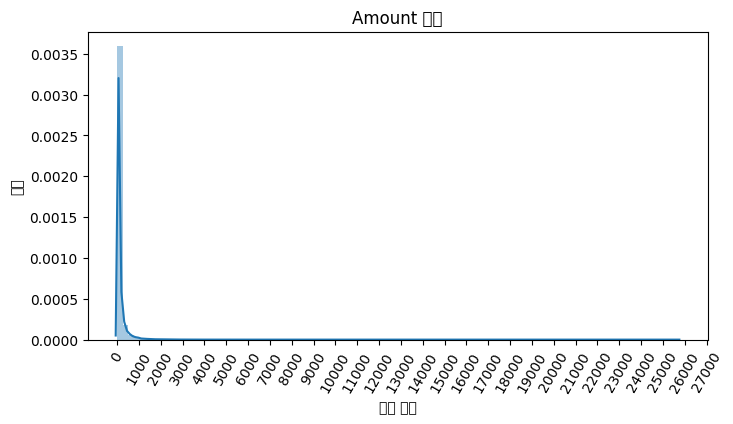

In [45]:
# STEP 2: Amount 피처 전처리
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(8, 4))
plt.xticks(range(0, 30000, 1000), rotation=60)
sns.distplot(card_df['Amount'], bins=100, kde=True)
plt.title('Amount 분포')
plt.xlabel('거래 금액')
plt.ylabel('빈도')
plt.show()
#오른 쪽으로 치우친 왜도 분포 (정규화 필요)

In [19]:
# STEP 2-A: StandardSclaer로 Amount 표준화 (평균=0, 표준편차=1)
# 효과: 피처 간 스케일 차이 제거 -> 경사하강법 기반 모델(로지스틱 회귀) 성능 향상
# 주의: 왜도는 제거되지 않음 (분포 형태는 유지, 범위만 변환)

from sklearn.preprocessing import StandardScaler # Added import statement

def get_preprocessed_df(df=None):
  df_copy = df.copy()
  scaler = StandardScaler()

  amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1)) # Changed .value to .values
  df_copy.insert(0, 'Amount_Scaled', amount_n)

  df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
  return df_copy

# 데이터 재분할 (새 전처리 함수 반영)
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('[STEP2-A] StandardSclaer 적용 - 로지스틱 회귀')
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, X_train, X_test, y_train, y_test)

print('[STEP2-A] StandasdScaler 적용 - LightGBM')
lgbm_clf = LGBMClassifier(
    n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False
)
get_model_train_eval(lgbm_clf, X_train, X_test, y_train, y_test)
# 정확도: 0.9995, 정밀도: 0.9569, 재현율: 0.7568, F1: 0.8453, AUC: 0.9717

[STEP2-A] StandardSclaer 적용 - 로지스틱 회귀
오차 행렬
[[85281    14]
 [   55    93]]
정확도: 0.9992
정밀도: 0.8692
재현율: 0.6284
F1: 0.7294
ROC AUC: 0.9706
[STEP2-A] StandasdScaler 적용 - LightGBM
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.129463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

In [44]:
# STEP 2-B: np.loglp 로그 변환
# StandardScaler보다 왜도 제거 효과 강함, 오른쪽 치우친(right-skewed) 분포를 정규 분포에 가깝게 변환

# STEP 2-A: StandarScaler로 Amount 표준화 (평균=0, 표준편차=1)
# 효과: 피처 간 스케일 차이 제거 -> 경사하강법 기반 모델(로지스틱 회귀) 성능 향상
# 주의: 왜도는 제거되지 않음 (분포 형태는 유지, 범위만 변환)

def get_preprocessed_df(df=None):
  df_copy = df.copy()

  amount_n = np.log1p(df_copy['Amount'])
  df_copy.insert(0, 'Amount_Scaled', amount_n)

  df_copy.drop(['Time'], axis=1, inplace=True)
  return df_copy

# 데이터 재분할 (새 전처리 함수 반영)
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('[STEP2-B] 로그 변환 적용 - 로지스틱 회귀')
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, X_train, X_test, y_train, y_test)

print('[STEP2-B] 로그 변환 적용 - LightGBM')
lgbm_clf = LGBMClassifier(
    n_estimators=1000,
    num_leaves=64,
    n_jobs=-1,
    boost_from_average=False
)
get_model_train_eval(lgbm_clf, X_train, X_test, y_train, y_test)
#정확도:0.9995, 정밀도:0.9576,재현율:0.7635,F1:0.8496,AUC:0.9796

[STEP2-B] 로그 변환 적용 - 로지스틱 회귀
오차 행렬
[[85282    13]
 [   60    88]]
정확도: 0.9991
정밀도: 0.8713
재현율: 0.5946
F1: 0.7068
ROC AUC: 0.9761
[STEP2-B] 로그 변환 적용 - LightGBM
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.065595 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 30
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

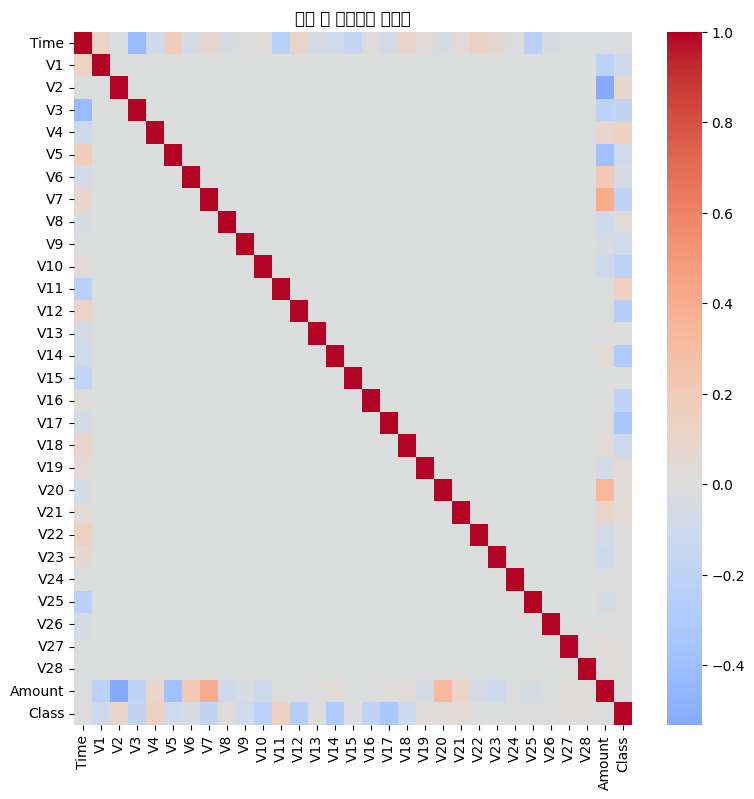

In [43]:
# STEP 3: 이상치 제거 - 상관관계 히트맵으로 핵심 피처 파악
import seaborn as sns
plt.figure(figsize=(9,9))
corr = card_df.corr() # 파이슨 상관계수 계산
sns.heatmap(
    corr, cmap ='coolwarm', center=0, annot=False
)
plt.title('피처 간 상관관계 히트맵')
plt.show()

In [22]:
# Class와의 상관관계만 추출해서 정렬
class_corr = card_df.corr()['Class'].sort_values()
print(class_corr)

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64


In [25]:
from operator import index
import numpy as np # numpy import 추가

#IQR 기반 이상치 감지 함수
def get_outlier(df=None, column=None, weight=1.5):
  fraud = df[df['Class'] == 1][column] # 사기 거래만 필터링
  q25 = np.percentile(fraud.values, 25) #Q1
  q75 = np.percentile(fraud.values, 75) #Q3
  iqr = q75 - q25 # IQR
  iqr_weight = iqr * weight
  # 정상 범위: [Q1 - 1.5 x IQR, Q3 + 1.5xIQR]
  lowest_val = q25 - iqr_weight
  highest_val = q75 + iqr_weight
  # 정상 범위를 벗어난 인덱스 추출
  outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
  print(f' Q1: {q25:.2f}, Q3: {q75:.2f}, IQR:{iqr:.2f}')
  print(f' 정상 범위: [{lowest_val:.2f}, {highest_val:.2f}]')
  return outlier_index

outlier_index = get_outlier(card_df, 'V14', weight=1.5)
print(f'이상치 인덱스: {list(outlier_index)}')
print(f' 이상치 개수: {len(outlier_index)}건')
print(f' -> 전체: {len(card_df)}건 중 {len(outlier_index)}건 제거 예정')

 Q1: -9.69, Q3: -4.28, IQR:5.41
 정상 범위: [-17.81, 3.83]
이상치 인덱스: [8296, 8615, 9035, 9252]
 이상치 개수: 4건
 -> 전체: 284807건 중 4건 제거 예정


In [27]:
# STEP 3: 이상치 제거 후 전처리 함수 업데이트
def get_preprocessed_df(df=None):
  df_copy = df.copy()

  #Amount 로그 변환
  amount_n = np.log1p(df_copy['Amount'])
  df_copy.insert(0, 'Amount_Scaled', amount_n)
  df_copy.drop(['Time','Amount'], axis=1, inplace=True)

  # V14 이상치 제거
  outlier_index = get_outlier(df=df_copy, column='V12', weight=1.5)
  df_copy.drop(outlier_index, axis=0, inplace=True)

  return df_copy

# 데이터 재분할 (새 전처리 함수 반영)
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('[STEP3] 이상치 제거 후 - 로지스틱 회귀')
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, X_train, X_test, y_train, y_test)

print('[STEP2-A] StandasdScaler 적용 - LightGBM')
lgbm_clf = LGBMClassifier(
    n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False
)
get_model_train_eval(lgbm_clf, X_train, X_test, y_train, y_test)

 Q1: -8.69, Q3: -2.97, IQR:5.71
 정상 범위: [-17.26, 5.60]
[STEP3] 이상치 제거 후 - 로지스틱 회귀
오차 행렬
[[85281    14]
 [   49    97]]
정확도: 0.9993
정밀도: 0.8739
재현율: 0.6644
F1: 0.7549
ROC AUC: 0.9858
[STEP2-A] StandasdScaler 적용 - LightGBM
[LightGBM] [Info] Number of positive: 340, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.126501 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199360, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

In [28]:
# STEP 4: SMOTE 오버 샘플링
from imblearn.over_sampling import SMOTE # pip install imbalanced-learn

smote = SMOTE(random_state=0)
#SMOTE는 반드시 학습 데이터에만 적용
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print('SMOTE 적용 후:')
print(f' X_train_over shape: {X_train_over.shape}, y_train_over: {y_train_over.shape}')
print(f'학습 데이터 사기 비율: {y_train_over.mean() * 100:.1f}%')
print('레이블 분포 (SMOTE 후)')
print(pd.Series(y_train_over).value_counts())
#0(정상)과 1(사기)이 1:1 비율로 균형 -> 불균형 문제 해소

SMOTE 적용 후:
 X_train_over shape: (398040, 29), y_train_over: (398040,)
학습 데이터 사기 비율: 50.0%
레이블 분포 (SMOTE 후)
Class
0    199020
1    199020
Name: count, dtype: int64


In [29]:
# STEP4: SMOTE 적용 후 로지스틱 회귀 학습
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, X_train_over,  X_test, y_train_over, y_test)

오차 행렬
[[83020  2275]
 [   11   135]]
정확도: 0.9732
정밀도: 0.0560
재현율: 0.9247
F1: 0.1056
ROC AUC: 0.9844


In [30]:
# STEP 4: SMOTE 적용 후 LightGBM
lgbm_clf = LGBMClassifier(
    n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False
)
get_model_train_eval(lgbm_clf, X_train_over, X_test, y_train_over, y_test)

[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.196292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

In [35]:
# 정밀도-재현율 곡선으로 최적 임계값 시각화
import matplotlib.pyplot as plt
def precision_recall_curve_plot(y_test, pred_proba_c1):
  precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)
  plt.figure(figsize=(8,6))
  n = thresholds.shape[0]
  # 정밀도 곡선
  plt.plot(thresholds, precisions[0:n],
           linestyle='--', label='precision(정밀도)', color='#3b82f6')
  # 재현율 곡선
  plt.plot(thresholds, recalls[0:n], label='Recall (재현율)', color='#ef4444')

  start, end = plt.xlim()
  plt.xticks(np.round(np.arange(start, end, 0.1), 2))
  plt.xlabel('Threshold(임계값)')
  plt.ylabel('Precision / Recall')
  plt.title('임계값별 정밀도, 재현율 변화\n(두 곡선의 교차점 = 균형 임계값)')
  plt.legend()
  plt.grid(alpha=0.3)
  plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

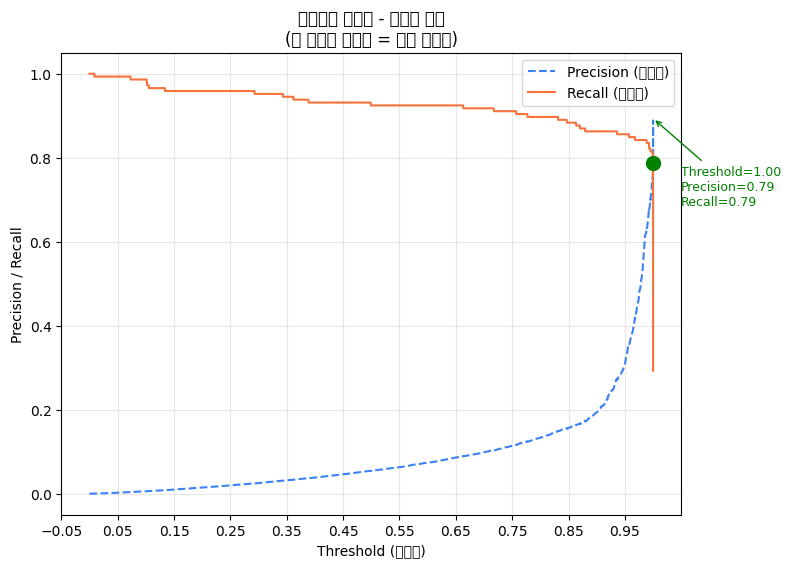

In [40]:
# 정밀도 재현율 곡선으로 최적 임계값 시각화
def precision_recall_curve_plot(y_test, pred_proba_c1):
  precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)
  plt.figure(figsize=(8, 6))
  n = thresholds.shape[0]
  # 정밀도 곡선
  plt.plot(thresholds, precisions[0:n],
           linestyle='--', label='Precision (정밀도)', color='#3b82f6')
  # 재헌율 곡선
  plt.plot(thresholds, recalls[:n],
           label='Recall (재현율)', color='#f6723b')

  # 두 곡선이 교차하는 지점의 임계값이 정밀도 재헌율 균형점
  # 시기 탐지 우선 -> 교차점보다 낮은 임계값 선택 (재헌율 높은것)

  # 교차점 찾기
  diff = precisions[:n] - recalls[:n]
  cross_idx = np.argmin(np.abs(diff)) # 두 값의 차이가 가장 작은 인덱스
  cross_threshold = thresholds[cross_idx]
  cross_precision = precisions[cross_idx]
  cross_recall = recalls[cross_idx]
  cross_value = (cross_threshold + cross_recall) / 2

  # 교차점 표시
  plt.scatter(cross_threshold, cross_precision, color='green', s=100, zorder=5)
  plt.annotate(
      f'Threshold={cross_threshold:.2f}\nPrecision={cross_precision:.2f}\nRecall={cross_recall:.2f}',
      xy = (cross_threshold, cross_value),
      xytext = (cross_threshold + 0.05, cross_precision - 0.1), # 텍스트 위치 오프셋
      fontsize = 9,
      color = 'green',
      arrowprops=dict(arrowstyle='->', color='green')
  )

  start, end = plt.xlim()
  plt.xticks(np.round(np.arange(start, end, 0.1), 2))
  plt.xlabel('Threshold (임계값)')
  plt.ylabel('Precision / Recall')
  plt.title('임계값별 정밀도 - 재헌율 변화\n(두 곡선의 교차점 = 균형 임계값)')
  plt.legend()
  plt.grid(alpha=0.3)
  plt.show()

precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])